In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, gaussian_kde, cauchy
from scipy import stats

np.random.seed(42)  # для воспроизводимости

## 1.1 Нормальное распределение N(6,4)

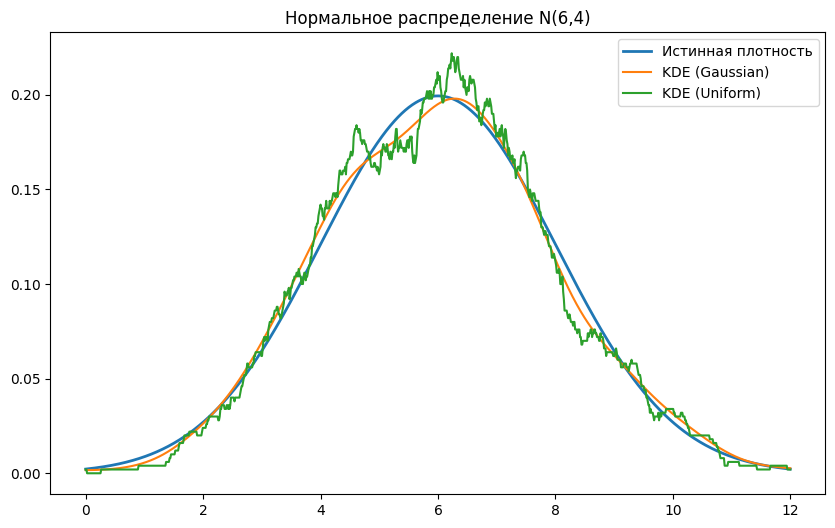

In [2]:
n = 500
mu, sigma = 6, 2  # std = sqrt(4)

sample_normal = np.random.normal(mu, sigma, n)

x = np.linspace(0, 12, 1000)

# Истинная плотность
true_density = norm.pdf(x, mu, sigma)

# KDE (гауссовское ядро)
kde_gauss = gaussian_kde(sample_normal)

# KDE (равномерное ядро)
def uniform_kernel(u):
    return np.where(np.abs(u) <= 1, 0.5, 0)

def kde_uniform(sample, x, h=0.5):
    return np.mean([uniform_kernel((x - xi) / h) for xi in sample], axis=0) / h

kde_unif = kde_uniform(sample_normal, x)

# График
plt.figure(figsize=(10,6))
plt.plot(x, true_density, label='Истинная плотность', linewidth=2)
plt.plot(x, kde_gauss(x), label='KDE (Gaussian)')
plt.plot(x, kde_unif, label='KDE (Uniform)')
plt.legend()
plt.title('Нормальное распределение N(6,4)')
plt.show()

## 1.2 Равномерное распределение [-2,3]

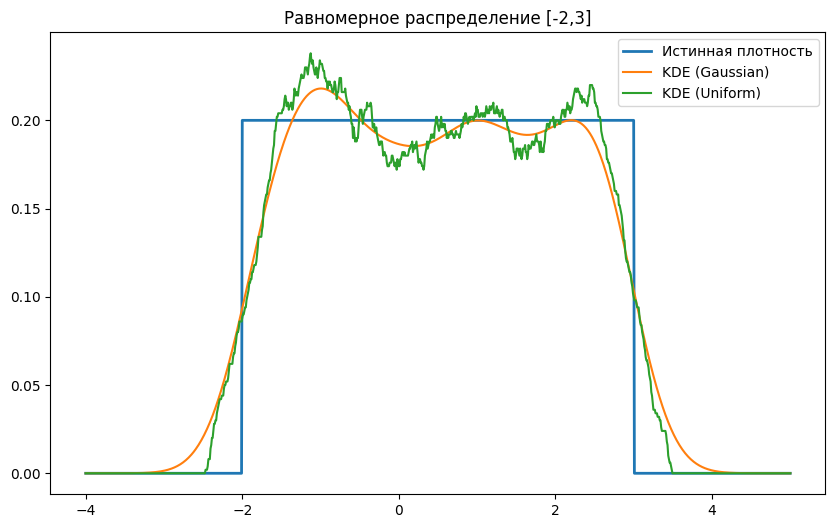

In [3]:
sample_uniform = np.random.uniform(-2, 3, n)

x = np.linspace(-4, 5, 1000)

# Истинная плотность
true_density = uniform.pdf(x, loc=-2, scale=5)

kde_gauss = gaussian_kde(sample_uniform)
kde_unif = kde_uniform(sample_uniform, x)

plt.figure(figsize=(10,6))
plt.plot(x, true_density, label='Истинная плотность', linewidth=2)
plt.plot(x, kde_gauss(x), label='KDE (Gaussian)')
plt.plot(x, kde_unif, label='KDE (Uniform)')
plt.legend()
plt.title('Равномерное распределение [-2,3]')
plt.show()

## 2.1 Делим выборку пополам

In [4]:
x_sample = np.random.normal(5, np.sqrt(3), n)

x1 = x_sample[:n//2]
x2 = x_sample[n//2:]

corr_halves = np.corrcoef(x1, x2)[0,1]
print("Корреляция между половинами:", corr_halves)

Корреляция между половинами: 0.10473661879490787


## Генерация Y

In [5]:
epsilon = np.random.normal(0, 1, n)
y_sample = 2 * x_sample - 7 + epsilon

### Корреляция + доверительный интервал

In [6]:
r = np.corrcoef(x_sample, y_sample)[0,1]
print("Корреляция X и Y:", r)

# Доверительный интервал через преобразование Фишера
z = np.arctanh(r)
se = 1 / np.sqrt(n - 3)

z_crit = stats.norm.ppf(0.975)

z_low = z - z_crit * se
z_high = z + z_crit * se

r_low = np.tanh(z_low)
r_high = np.tanh(z_high)

print("95% доверительный интервал:", (r_low, r_high))

Корреляция X и Y: 0.9615834139820574
95% доверительный интервал: (np.float64(0.9543667636847325), np.float64(0.9676776649317166))


## 3.0 Генерация X

In [7]:
x_sample = np.random.normal(-4, np.sqrt(2), n)

## 3.1 Три варианта шума

In [8]:
# 1 — нормальный шум
eps1 = np.random.normal(0, 1, n)
y1 = -3 * x_sample + 5 + eps1

# 2 — равномерный шум
eps2 = np.random.uniform(-4, 4, n)
y2 = -3 * x_sample + 5 + eps2

# 3 — Коши
eps3 = cauchy.rvs(size=n)
y3 = -3 * x_sample + 5 + eps3

## 3.2 Регрессии

In [10]:
def fit_regression(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    return slope, intercept

b1, a1 = fit_regression(x_sample, y1)
b2, a2 = fit_regression(x_sample, y2)
b3, a3 = fit_regression(x_sample, y3)

## 3.3 Графики

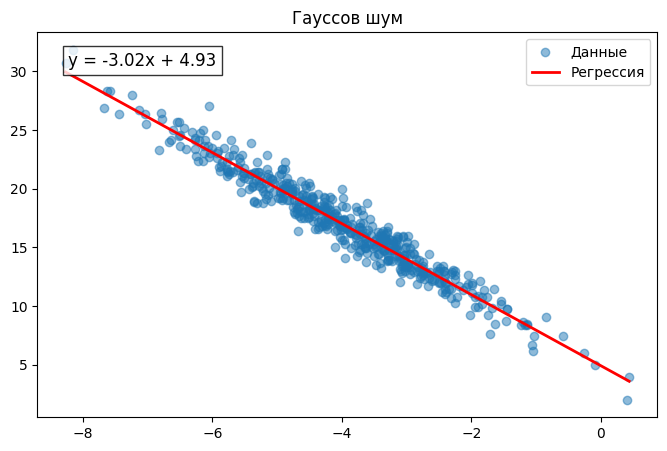

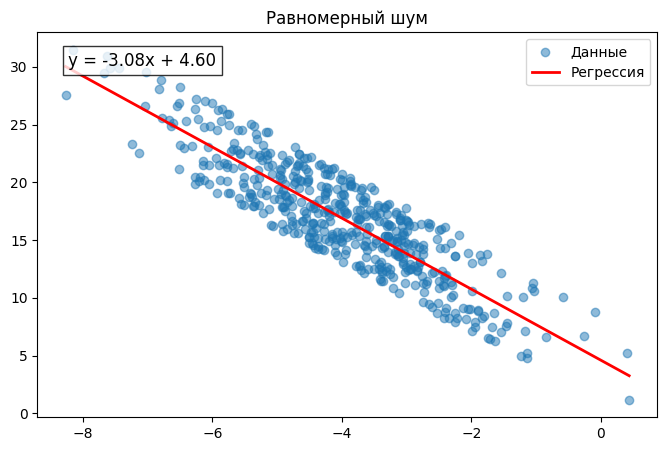

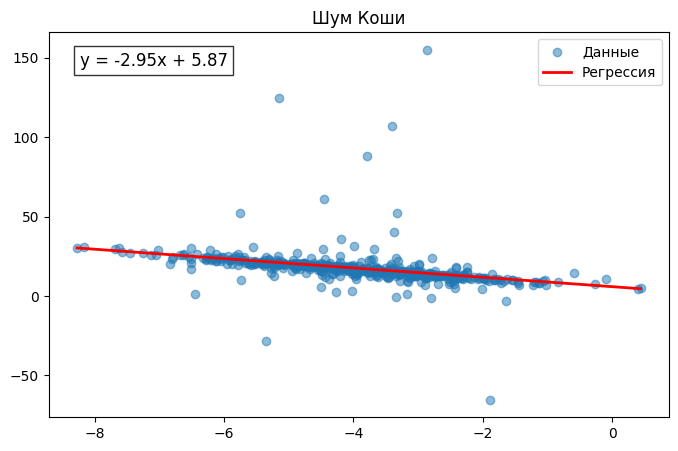

In [15]:
def plot_regression(x, y, slope, intercept, title):
    plt.figure(figsize=(8,5))
    plt.scatter(x, y, alpha=0.5, label='Данные')
    
    x_line = np.linspace(min(x), max(x), 100)
    y_line = slope * x_line + intercept
    
    plt.plot(x_line, y_line, color='red', linewidth=2, label='Регрессия')
    
    equation = f"y = {slope:.2f}x + {intercept:.2f}"
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.title(title)
    plt.legend()
    plt.show()

plot_regression(x_sample, y1, b1, a1, "Гауссов шум")
plot_regression(x_sample, y2, b2, a2, "Равномерный шум")
plot_regression(x_sample, y3, b3, a3, "Шум Коши")